In [1]:
#box-model approach: inflow - outflow + sources - sinks

In [4]:
import numpy as np
import matplotlib.pyplot as plt

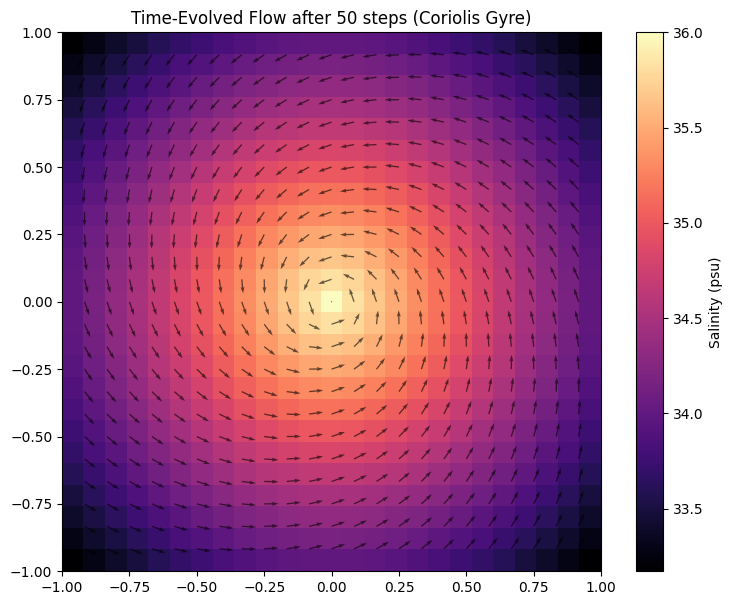

In [ ]:
#the same thing as before but stronger coriolis and easier to manage time step for demo
n = 25
x = np.linspace(-1, 1, n)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)

#driving Force = here it is just salinity gradient
salinity = 34 + 2 * (1 - np.sqrt(X**2 + Y**2))
grad_y, grad_x = np.gradient(salinity)

#time evol
u, v = np.zeros((n, n)), np.zeros((n, n))
f = 0.5      #coriolis parameter (strong)
dt = 0.1     #time step
steps = 50   #number of iter

#simulationloop
for _ in range(steps):
    #acceleration = Pressure Gradient + Coriolis Force
    # equal to :(du/dt = PGF_x + f*v) , (dv/dt = PGF_y - f*u)
    u_new = u + (grad_x + f * v) * dt
    v_new = v + (grad_y - f * u) * dt
    
    #boundary condition: No flow at land edges
    u_new[0,:] = u_new[-1,:] = u_new[:,0] = u_new[:,-1] = 0
    v_new[0,:] = v_new[-1,:] = v_new[:,0] = v_new[:,-1] = 0
    
    u, v = u_new, v_new

#Plotting the final state
plt.figure(figsize=(9, 7))
im = plt.imshow(salinity, extent=[-1, 1, -1, 1], cmap='magma', origin='lower')
plt.quiver(X, Y, u, v, color='black', alpha=0.6)
plt.title(f'Time-Evolved Flow after {steps} steps (Coriolis Gyre)')
plt.colorbar(im, label='Salinity (psu)')
plt.show()

In [61]:
#the edges here are not taking into account the coastal boundary conditions
#then salinity would be different

In [62]:
#since coriolis is used , the water is converging at the centre